In [147]:
import gymnasium as gym
import minihack  # This import registers MiniHack environments

In [148]:
env_id = "MiniHack-KeyRoom-S15-v0"
env = gym.make(env_id)
seed = 103

In [149]:
obs, _ = env.reset(seed=seed)

In [150]:
env.render()


Hello Agent, welcome to NetHack!  You are a chaotic male human Rogue.           
                                                                                
                                                                                
                                                                                
                               ---          ----                                
                               |..          ...|                                
                               |..          ...|                                
                               |..         ....|                                
                               |..         ....|                                
                               |...       ...(.|                                
                               |...-------.....|                                
                               |...............|                                
                           

In [151]:
for _ in range(8):
    o = env.step(1)

In [152]:
env.render()


                                                                                
                                                                                
                                                                                
                                                                                
                               ---       -------                                
                               |..       |.....|                                
                               |..       |.....|                                
                               |..       |.....|                                
                               |..       |.....|                                
                               |...      |...(.|                                
                               |...-------.....|                                
                               |...............|                                
                           

In [153]:
for _ in range(9):
    o = env.step(0)
env.render()


                                                                                
                                                                                
                                                                                
                                                                                
                               ---       -------                                
                               |..       |.....|                                
                               |..       |.....|                                
                               |..       |.....|                                
                               |..       |.....|                                
                               |...      |...(.|                                
                               |...-------...@.|                                
                               |...............|                                
                           

In [154]:
o=env.step(0)
env.render()


You see here a key named The Master Key of Thievery.                            
                                                                                
                                                                                
                                                                                
                               ---       -------                                
                               |..       |.....|                                
                               |..       |.....|                                
                               |..       |.....|                                
                               |..       |.....|                                
                               |...      |...@.|                                
                               |...-------.....|                                
                               |...............|                                
                           

In [158]:
o=env.step(3)
env.render()


It's a wall.                                                                    
                                                                                
                                                                                
                                                                                
                               ---       -------                                
                               |..       |.....|                                
                               |..       |.....|                                
                               |..       |.....|                                
                               |..       |.....|                                
                               |...      |@..(.|                                
                               |...-------.....|                                
                               |...............|                                
                           

In [187]:
o=env.step(3)
env.render()


                                                                                
                                                                                
                                                                                
                                                                                
                               -----     -------                                
                               |...+     |.....|                                
                               |...|     |.....|                                
                               |...|     |.....|                                
                               |...|     |.....|                                
                               |...|     |...(.|                                
                               |...-------.....|                                
                               |..@............|                                
                           

In [193]:
o = env.step(0)
env.render()


                                                                                
                                                                                
                                                                                
                                                                                
                               -----     -------                                
                               |..@+     |.....|                                
                               |...|     |.....|                                
                               |...|     |.....|                                
                               |...|     |.....|                                
                               |...|     |...(.|                                
                               |...-------.....|                                
                               |...............|                                
                           

In [194]:
o = env.step(1)
env.render()


This door is locked.                                                            
                                                                                
                                                                                
                                                                                
                               -----     -------                                
                               |..@+     |.....|                                
                               |...|     |.....|                                
                               |...|     |.....|                                
                               |...|     |.....|                                
                               |...|     |...(.|                                
                               |...-------.....|                                
                               |...............|                                
                           

In [33]:
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import pandas as pd
import matplotlib.colors as mcolors

In [119]:
sns.set_theme(context="paper")
api = wandb.Api()

In [120]:
room_run_ids = {
    "no_hmm_no_intrinsic": "xchen-catkin-ucl/SequentialSkillRL-Ablations/glofz1ho",
    "no_hmm_dyn_only": "xchen-catkin-ucl/SequentialSkillRL-Ablations/7xhnsr8u",
    "no_hmm_rnd": "xchen-catkin-ucl/SequentialSkillRL-Ablations/agj8krmq",
    "hmm_no_intrinsic": "xchen-catkin-ucl/SequentialSkillRL-Ablations/22v74bws",
    "hmm_dyn_only": "xchen-catkin-ucl/SequentialSkillRL-Ablations/uxdmmzzs",
    "hmm_skill_only": "xchen-catkin-ucl/SequentialSkillRL-Ablations/odrf7hpg",
    "hmm_trans_only": "xchen-catkin-ucl/SequentialSkillRL-Ablations/0hrl08cb",
    "hmm_full_curiosity": "xchen-catkin-ucl/SequentialSkillRL-Ablations/26jwfj0f",
    "hmm_rnd": "xchen-catkin-ucl/SequentialSkillRL-Ablations/fsm86dmp"
}

river_run_ids = {
    "no_hmm_no_intrinsic": "xchen-catkin-ucl/SequentialSkillRL-Ablations/odrf7hpg",
    "no_hmm_dyn_only": "xchen-catkin-ucl/SequentialSkillRL-Ablations/nxb9fag8",
    "hmm_dyn_only": "xchen-catkin-ucl/SequentialSkillRL-Ablations/6pi9ijl7",
    "hmm_full_curiosity": "xchen-catkin-ucl/SequentialSkillRL-Ablations/wbzm4lgu",
    "hmm_rnd": "xchen-catkin-ucl/SequentialSkillRL-Ablations/w4f6if3l"
}

In [138]:
def plot_data(run_ids, metric_name, title, y_label, x_label, figsize=(12, 8)):
    """
    Plot metrics from multiple W&B runs with improved styling and error handling.
    
    Args:
        run_ids: Dictionary mapping run names to W&B run IDs
        metric_name: Name of the metric to plot
        title: Plot title
        figsize: Figure size tuple
    """

    # Light high-key palettes (HCL in Seaborn)
    names = list(run_ids.keys())
    no_hmm_num = sum(1 for name in names if name.startswith("no_hmm"))
    hmm_num = sum(1 for name in names if name.startswith("hmm"))
    
    # Light high-key palettes (HCL in Seaborn)
    no_hmm_palette = sns.color_palette("rocket", n_colors=no_hmm_num)  # cool
    hmm_palette    = sns.color_palette("mako", n_colors=hmm_num)     # warm
    
    no_hmm_palette = sns.cubehelix_palette(rot=-0.2, gamma=1.8)
    hmm_palette = sns.cubehelix_palette(rot=0.2, gamma=1.8)

    NO_HMM = [mcolors.to_hex(color) for color in no_hmm_palette]
    HMM    = [mcolors.to_hex(color) for color in hmm_palette]

    # line styles for redundancy
    STYLE_NO_HMM = dict(lw=4.0, ls="--", alpha=0.95)   # dashed for no_hmm
    STYLE_HMM    = dict(lw=4.2, ls="-",  alpha=0.95)   # solid for hmm

    # assign colors/styles
    color_map, style_map = {}, {}
    no_hmm_i, hmm_i = 0, 0
    fig, ax = plt.subplots(figsize=figsize)
    
    successful_plots = 0
    for i, (key, run_id) in enumerate(run_ids.items()):
        try:
            run = api.run(run_id)
            history = run.history()
            
            # Check if metric exists
            if metric_name not in history.columns:
                print(f"⚠️ Metric '{metric_name}' not found for {key}. Available metrics: {list(history.columns)[:10]}...")
                continue
                
            xs = history["_step"].values
            ys = history[metric_name].values
            
            # Remove NaN values
            mask = ~(pd.isna(xs) | pd.isna(ys))
            xs_clean = xs[mask]
            ys_clean = ys[mask]
            
            if len(xs_clean) == 0:
                print(f"⚠️ No valid data points for {key}")
                continue
            
            if key.startswith("no_hmm"):
                color_map[key] = NO_HMM[no_hmm_i % len(NO_HMM)]
                style_map[key] = STYLE_NO_HMM
                no_hmm_i += 1
            else:
                color_map[key] = HMM[hmm_i % len(HMM)]
                style_map[key] = STYLE_HMM
                hmm_i += 1
            sns.lineplot(x=xs_clean, y=ys_clean, ax=ax, label=key.replace("_"," "), color=color_map[key], **style_map[key])
            successful_plots += 1
            
        except Exception as e:
            print(f"❌ Error loading {key}: {e}")
            continue
    
    if successful_plots == 0:
        print("❌ No successful plots generated!")
        return
    
    # Enhanced styling - fix the title setting
    ax.set_title(title, fontsize=20)
    ax.set_xlabel(x_label, fontsize=18)
    ax.set_ylabel(y_label, fontsize=18)
    
    # Improved legend
    legend = ax.legend(frameon=True, fontsize=20)
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_linewidth(1.0)
    # Grid and styling
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tight layout to prevent clipping
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Successfully plotted {successful_plots}/{len(run_ids)} runs")

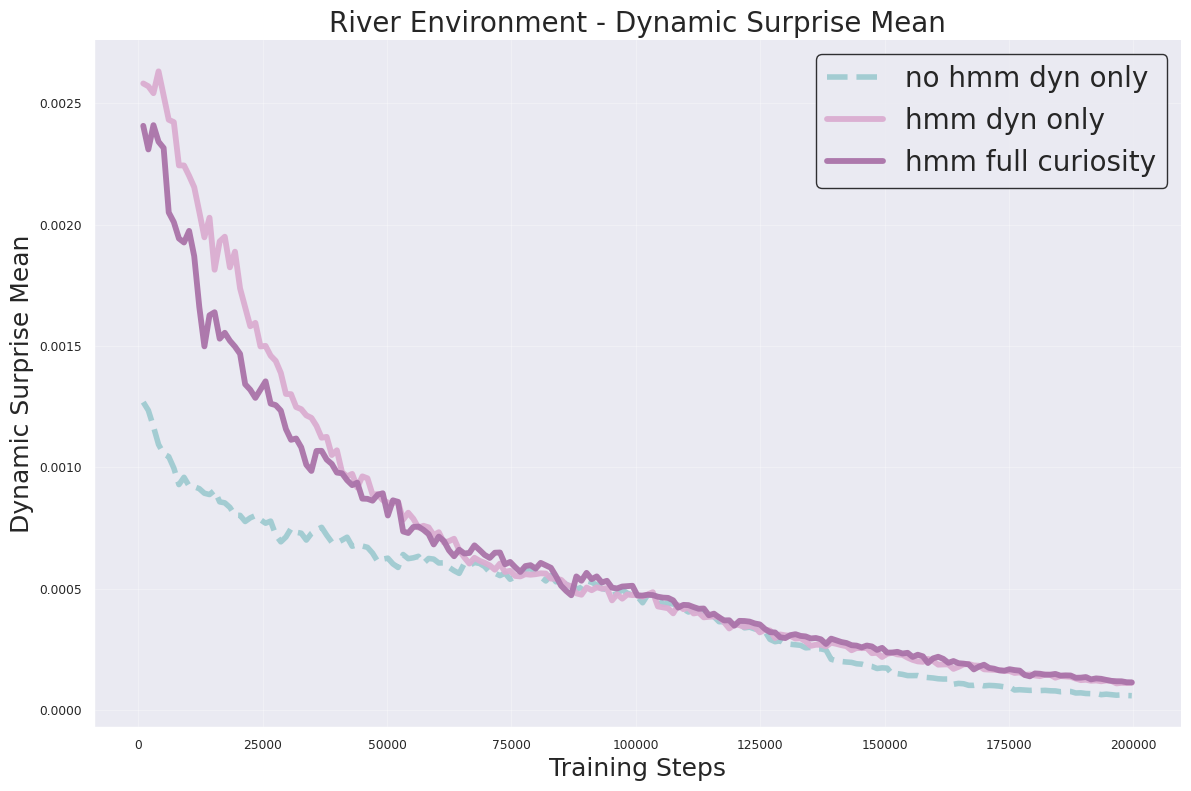

✅ Successfully plotted 3/3 runs


In [145]:
has_runs = {k: v for k, v in river_run_ids.items() if "dyn" in k or "full" in k}
plot_data(has_runs, "int/dyn_mean", "River Environment - Dynamic Surprise Mean", "Dynamic Surprise Mean", "Training Steps")

In [1]:
from rl.ppo import PPOConfig, CuriosityConfig, HMMOnlineConfig, VAEOnlineConfig, TrainConfig
from training.online_rl import train_online_ppo_with_pretrained_models
import math
import torch
import logging
# Calculate PPO updates from total steps
num_envs = 8
rollout_len = 128
total_steps = 200000
ppo_updates = total_steps // (num_envs * rollout_len)
env_name = "MiniHack-River-Narrow-v0"
train_seed = 51
eval_seed = 311
resume_repo_id = "CatkinChen/nethack-ppo-ablation-baseline_full_curiosity"
vae_revision = None
hmm_revision = None

# Base PPO Configuration (same for all ablations)
ppo_config = PPOConfig(
    num_envs=num_envs,
    rollout_len=rollout_len,
    total_updates=ppo_updates,
    minibatch_envs=4,
    epochs_per_update=4,
    gamma=0.99,
    gae_lambda=0.95,
    clip_coef=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    learning_rate=3e-4,
    vf_learning_rate=None,  # Use same as learning_rate
    policy_uses_skill=True,  # Will be overridden for no_hmm mode
    deterministic_eval=False
)

full_curiosity_config = CuriosityConfig(
    use_dyn_kl=True,           # Dynamics surprise
    use_skill_entropy=True,    # Skill entropy with boundary gating
    use_skill_transition_novelty=True,  # Skill transition novelty
    use_rnd=False,
    # Skill boundary gating
    use_skill_boundary_gate=True,
    tau_dyn=total_steps / math.log(20),
    tau_hdp=total_steps / math.log(20),
    tau_stn=total_steps / math.log(20),
    tau_rnd=total_steps / math.log(20),
    intr_tau_dyn=180.0,
    intr_tau_hdp=1.0,
    intr_tau_trans=1.0,
    intr_tau_rnd=1.0
)

dyn_curiosity_config = CuriosityConfig(
    use_dyn_kl=True,           # Only dynamics surprise
    use_skill_entropy=False,
    use_skill_transition_novelty=False,
    use_rnd=False,
    tau_dyn=total_steps / math.log(20),
    tau_hdp=total_steps / math.log(20),
    tau_stn=total_steps / math.log(20),
    tau_rnd=total_steps / math.log(20),
    intr_tau_dyn=180.0,
    intr_tau_hdp=1.0,
    intr_tau_trans=1.0,
    intr_tau_rnd=1.0
)

hmm_config = HMMOnlineConfig(
    hmm_update_every=5_120,   # Update HMM every ~5 rollouts
    hmm_update_growth=1.2,    # Growth factor for update interval
    hmm_update_every_cap=12_000, # Cap for update interval
    hmm_fit_window=400_000,    # Use 400k steps for HMM fitting
    hmm_max_batch_size=128,    # Cap batch size to prevent OOM (was causing 20GB allocations)
    hmm_max_iters=5,           # Up to 5 iterations per update
    hmm_tol=1e-2,
    hmm_elbo_drop_tol=1e-2,
    rho_emission=0.05,        # Streaming blend rate
    rho_transition=None,       # Use same as emission
    optimise_pi=True,
    pi_steps=10,                # π optimization steps
    pi_lr=5e-4,                 # π optimization learning rate
    pi_early_stopping_patience=1,    # Early stopping patience
    pi_early_stopping_min_delta=1e-2, # Early stopping min delta
    emission_mode = "student_t",          # "sample" or "mean" or "expected" or "student_t"
    student_t_use_sample = True      # if using student_t, use sampled z for logB (else mean)
)

vae_config = VAEOnlineConfig(
    vae_update_every=5_120,       # Match HMM update frequency
    vae_update_growth=1.2,        # Same growth pattern as HMM
    vae_update_every_cap=12_000,  # Same cap as HMM
    vae_lr=3e-5,                  # Learning rate for VAE updates
    vae_steps_per_call=4,        # Number of gradient steps per VAE update
)

train_config = TrainConfig(
    env_id=env_name,
    train_seed=train_seed,
    eval_seed=eval_seed,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    save_every=10_000,
    eval_every=10_000,
    test_mode=True,
    eval_episodes=100,
    use_hmm=True
)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler()  # Also show in console
    ]
)
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

In [2]:
results = train_online_ppo_with_pretrained_models(
    None,
    None,
    
    # Use config objects for full control
    ppo_config,
    full_curiosity_config,
    hmm_config,
    vae_config,
    None,
    train_config,
    
    # Model revision control
    vae_revision=vae_revision,
    hmm_revision=hmm_revision,
    
    # Resume training from existing PPO checkpoint (new!)
    ppo_repo_id=resume_repo_id,
    resume_training=True,
    reset_global_steps=True,
    logger=logger
)

2025-09-29 03:05:33,623 - __main__ - INFO - ================================================================================
2025-09-29 03:05:33,625 - __main__ - INFO - Starting Online PPO Training with Pretrained Models
2025-09-29 03:05:33,625 - __main__ - INFO - Environment: MiniHack-River-Narrow-v0
2025-09-29 03:05:33,625 - __main__ - INFO - VAE Repository: None
2025-09-29 03:05:33,626 - __main__ - INFO - HMM Repository: None
2025-09-29 03:05:33,626 - __main__ - INFO - Total Timesteps: 195
2025-09-29 03:05:33,626 - __main__ - INFO - ================================================================================
2025-09-29 03:05:33,627 - __main__ - INFO - 🔧 Using device: cuda
2025-09-29 03:05:33,627 - __main__ - INFO - 🔄 Resume mode: Loading all models from unified repo: CatkinChen/nethack-ppo-ablation-baseline_full_curiosity
2025-09-29 03:05:33,628 - __main__ - INFO - 🎨 Loading VAE from unified repo...


📥 Downloading model config from CatkinChen/nethack-ppo-ablation-baseline_full_curiosity...
⚠️  Could not load config.json: 404 Client Error. (Request ID: Root=1-68d9f77d-11539eb163f8098d7d2e46a1;9ec53c1c-ba9b-4695-90d5-908120e83533)

Entry Not Found for url: https://huggingface.co/CatkinChen/nethack-ppo-ablation-baseline_full_curiosity/resolve/main/config.json.
🔄 Attempting to extract config from model checkpoint...


2025-09-29 03:05:34,234 - __main__ - INFO - ✅ VAE loaded from vae_model.pth
2025-09-29 03:05:34,235 - __main__ - INFO - 🧠 Loading HMM from unified repo...


📋 Model config extracted from checkpoint: {'char_emb': 16, 'color_emb': 4, 'role_emb': 8, 'race_emb': 4, 'gend_emb': 2, 'align_emb': 2, 'encoder_dropout': 0.1, 'decoder_dropout': 0.1, 'latent_dim': 96, 'bag_dim': 16, 'low_rank': 0, 'attn_queries': 2, 'map_feat_channels': 96, 'stat_feat_channels': 16, 'msg_emb': 32, 'msg_hidden': 12, 'ego_window': 11, 'ego_classes': 17, 'map_dec_base_ch': 64, 'stats_cond_dim': 19, 'msg_ch': 128, 'action_dim': 121, 'forward_hidden': 256, 'use_world_model': True, 'gru_hidden': 256, 'use_inverse_dynamics': True, 'goal_dir_dim': 2, 'passability_dirs': 8, 'value_horizons': [1, 5, 10], 'skill_num': 40, 'gamma': 0.95, 'goal_prefer': '>', 'prior_mode': 'hmm', 'initial_prior_blend_alpha': 0.1, 'final_prior_blend_alpha': 0.6, 'prior_blend_shape': 'cosine', 'raw_modality_weights': {'ego_class': 5.0, 'passability': 5.0, 'safety': 5.0, 'reward': 0.5, 'done': 1.0, 'value_k': 1.0, 'bag': 3.0, 'stats': 0.5, 'msg': 1.0, 'goal': 3.0, 'occupy': 0.5, 'forward': 5.0, 'inver

2025-09-29 03:05:34,599 - __main__ - INFO - ✅ HMM loaded from hmm_model.pt
2025-09-29 03:05:34,599 - __main__ - INFO - ✅ VAE model loaded successfully
2025-09-29 03:05:34,600 - __main__ - INFO -    - Latent dimension: 96
2025-09-29 03:05:34,600 - __main__ - INFO -    - Skills: 40
2025-09-29 03:05:34,600 - __main__ - INFO - ✅ HMM model loaded successfully
2025-09-29 03:05:34,601 - __main__ - INFO -    🏷️  HMM Round: None
2025-09-29 03:05:34,601 - __main__ - INFO -    📅 Created: 2025-09-28T03:14:16.150718
2025-09-29 03:05:34,601 - __main__ - INFO - 🎮 Creating environment: MiniHack-River-Narrow-v0
2025-09-29 03:05:34,602 - nle.env.base - INFO - Not saving any NLE data.
2025-09-29 03:05:34,620 - __main__ - INFO -    - Observation space: Dict('blstats': Box(-2147483648, 2147483647, (27,), int64), 'chars': Box(0, 255, (21, 79), uint8), 'chars_crop': Box(0, 255, (9, 9), uint8), 'colors': Box(0, 15, (21, 79), uint8), 'colors_crop': Box(0, 15, (9, 9), uint8), 'glyphs': Box(0, 5976, (21, 79), in

✅ HMM loaded successfully from HuggingFace: CatkinChen/nethack-ppo-ablation-baseline_full_curiosity
🎯 Round: 4, Device: cuda
🎮 Action Adapter Setup:
   Environment: MiniHack-River-Narrow-v0
   Total NLE actions: 121
   Allowed actions from env: [107, 108, 106, 104, 117, 110, 98, 121]
   Allowed global indices: [0, 1, 2, 3, 4, 5, 6, 7]
   Action mappings: ['local_0->global_0(CompassDirection.N)', 'local_1->global_1(CompassDirection.E)', 'local_2->global_2(CompassDirection.S)', 'local_3->global_3(CompassDirection.W)', 'local_4->global_4(CompassDirection.NE)', 'local_5->global_5(CompassDirection.SE)', 'local_6->global_6(CompassDirection.SW)', 'local_7->global_7(CompassDirection.NW)']
   Unmapped global indices: [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]... (total: 113)
   Action mask shape: torch.Size([8, 121])
   Global2local shape: torch.Size([8, 121])
   Valid actions count: 8/121



2025-09-29 03:05:35,738 - __main__ - INFO - ✅ PPO trainer initialized successfully
2025-09-29 03:05:35,739 - __main__ - INFO - 🔄 Loading existing PPO checkpoint for continuation...
2025-09-29 03:05:35,739 - __main__ - INFO - 📥 Loading PPO checkpoint from HuggingFace: CatkinChen/nethack-ppo-ablation-baseline_full_curiosity
2025-09-29 03:05:35,896 - __main__ - INFO - ✅ PPO checkpoint loaded from HuggingFace
2025-09-29 03:05:35,897 - __main__ - INFO - ✅ Actor-critic model state restored
2025-09-29 03:05:35,898 - __main__ - INFO - ✅ Optimizer state restored
2025-09-29 03:05:35,898 - __main__ - INFO - ✅ Training resumed from step 199,680
2025-09-29 03:05:35,898 - __main__ - INFO - 🔄 Global step counter reset to 0 as requested
2025-09-29 03:05:35,898 - __main__ - INFO - ℹ️  Loaded training configuration from checkpoint
2025-09-29 03:05:35,899 - __main__ - WARNING - ⚠️  Environment changed: None → MiniHack-River-Narrow-v0
2025-09-29 03:05:35,899 - __main__ - INFO - 🎯 PPO checkpoint restoratio

In [3]:
results.keys()

dict_keys(['successful_trajectories', 'successful_viterbi_paths', 'success_rate', 'successful_returns', 'successful_lengths', 'successful_indices', 'all_returns', 'all_lengths', 'all_success_indicators', 'coverage_stats', 'episodes_terminated', 'episodes_truncated', 'evaluation_time', 'skill_boundary_mass_rates', 'skill_boundary_bool_rates', 'skill_entropies', 'used_skills_counts', 'effective_K_values'])

In [3]:
results['success_rate']

0.37

In [4]:
results['successful_lengths']

[65,
 68,
 41,
 56,
 161,
 55,
 38,
 32,
 151,
 64,
 82,
 95,
 64,
 37,
 111,
 55,
 102,
 50,
 52,
 83,
 51,
 44,
 41,
 32,
 122,
 44,
 29,
 291,
 52,
 276,
 93,
 259,
 55,
 55,
 106,
 80,
 184]

In [36]:
skills = torch.tensor(results['successful_trajectories'][0]['skills'])

In [37]:
skills.shape

torch.Size([65, 40])

In [38]:
skills.argmax(dim=-1)

tensor([25,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 25,
         9,  9, 25,  9,  9, 25,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,
         9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,
         9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9])

In [13]:
from nle.nethack import tty_render

In [39]:
obs = results['successful_trajectories'][0]['observations']
actions = results['successful_trajectories'][0]['actions']
rewards = results['successful_trajectories'][0]['rewards']

In [49]:
actions[40]

1

In [16]:
def print_obs(obs, idx):
    chars = torch.tensor(obs[idx]['chars'], dtype=torch.long)
    colors = torch.tensor(obs[idx]['colors'], dtype=torch.long)
    if chars.dim() == 3:
        chars = chars.squeeze(0)
        colors = colors.squeeze(0)
    print(tty_render(chars, colors))

In [57]:
print_obs(obs, 18)


                                                                               
                                                                               
                                                                               
                                                                               
                                                                               
                                                                               
                                                                               
                          .....<...........@}                                  
                          ..................}                                  
                          . `..........`....}                                  
                          ..................}                                  
                          ....`........`....}                                  
                          .............

In [54]:
''.join([chr(c) for c in obs[41]['message'] if c != 0])

'Pheew!  That was close.'